# Titanic 분류 모델 (RandomForestClassifier, Lv4)

Seaborn Titanic 데이터로 **승객 생존 여부(survived)** 를 예측하는 분류 예제입니다.

이번 Lv4 예제의 핵심은 모델보다 **검증 설계와 튜닝 순서**입니다.

- 데이터는 `seaborn.load_dataset('titanic')`에서 가져옵니다.
- 타깃 `survived`는 0/1 이진 분류 문제입니다.
- 학습/테스트 분리에서 **층화추출(stratify)** 을 사용합니다.
- 교차검증도 **StratifiedKFold** 로 진행합니다.
- 모델은 **RandomForestClassifier** 를 사용합니다.
- `Pipeline + ColumnTransformer` 안에서 결측치 처리와 One-hot Encoding을 수행합니다.
- `GridSearchCV` 로 RandomForest 하이퍼파라미터 튜닝을 진행합니다.

> 오늘의 목표: “분류 문제에서 층화추출과 교차검증, Pipeline, 하이퍼파라미터 튜닝을 한 흐름으로 연결한다.”


## 1. 환경설정

In [2]:
import sys
import platform
import warnings

# -------------------------------------------------------------------------
# 1. Google Colab / 리눅스 환경 한글 폰트(나눔고딕) 강제 설치 및 캐시 초기화
# -------------------------------------------------------------------------
# Darwin(macOS)이 아닌 리눅스 기반 환경(Colab)일 때만 시스템 폰트를 다운로드합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# -------------------------------------------------------------------------
# 2. 데이터 과학, 통계 분석 및 가설 검정 필수 데이터 라이브러리 로드
# -------------------------------------------------------------------------
import numpy as np               # 고성능 수치 연산 및 다차원 행렬 처리를 위한 NumPy
import pandas as pd              # 데이터프레임 구조 및 변형 전처리를 위한 Pandas
import matplotlib.pyplot as plt  # 기본 차트 및 객체지향 시각화 제어를 위한 핵심 도구
import matplotlib.font_manager as fm # 시스템에 설치된 한글 폰트를 등록하기 위한 폰트 매니저
import seaborn as sns            # 통계 기반의 미려하고 고도화된 그래프 출력을 위한 Seaborn
from scipy import stats          # 전처리 전후 특성 변화 검정 및 기초 통계 분석용 SciPy 패키지

# -------------------------------------------------------------------------
# 3. Scikit-learn 1.6.1 기반 모델 검증 및 하이퍼파라미터 튜닝 모듈 로드
# -------------------------------------------------------------------------
import sklearn
from sklearn.datasets import make_classification       # 정형 분류 데이터셋 가상 생성을 위한 함수
from sklearn.model_selection import (
    train_test_split,    # 학습용/테스트용 데이터 분할 도구
    GridSearchCV,        # 최적 하이퍼파라미터 탐색 격자 수행 도구
    StratifiedKFold,     # 불균형 비율을 유지하는 층화 K-폴드 교차검증 정의 객체
    cross_validate       # 교차검증 세부 지표 다중 평가 함수
)

# -------------------------------------------------------------------------
# 4. 엔드투엔드 파이프라인 구성을 위한 핵심 전처리 모듈 로드
# -------------------------------------------------------------------------
from sklearn.pipeline import Pipeline               # 전처리 + 모델링 공정을 하나로 결합하는 파이프라인
from sklearn.compose import ColumnTransformer       # 변수 속성(수치형/범주형)별로 전처리를 조준 실행하는 변환기
from sklearn.impute import SimpleImputer            # 데이터 결측치(NaN) 보간용 임퓨터

# [StandardScaler 모듈 소개]
# - 연속형(Numerical) 수치 특성들의 평균을 0, 표준편차를 1로 변환하는 '표준화(Z-score Normalization)'를 수행합니다.
# - 변수마다 각기 다른 단위를 정규화하여, 특정 변수(예: Fare)의 큰 절대값이 모델 학습이나 거리 계산을 지배하는 왜곡을 원천 차단합니다.
# - 특히 내부적으로 유클리드 거리를 측정하는 k-NN, SVM 및 SMOTE 계열의 샘플링 알고리즘 전처리 단계에서 필수적인 역할을 수행합니다.
# [OneHotEncoder 모듈 소개]
# - 기계학습 모델이 연산할 수 없는 문자형(Categorical) 범주 데이터를 독립적인 이진수(0 또는 1) 벡터 공간으로 변환합니다.
# - Scikit-learn 1.6.1 버전 기준, 'sparse_output=False'를 설정하여 가밀집 행렬(Dense Matrix) 형태의 NumPy 배열을 반환하도록 제어합니다.
# - 'drop="first"' 옵션을 함께 사용하면 중복 더미 변수 간의 통계적 결합(다중공선성) 문제를 예방하여 모형의 일반화 성능을 높입니다.
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# -------------------------------------------------------------------------
# 5. 분류 모델 및 다각적 성능 평가지표 모듈 로드
# -------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression    # 선형 기준 베이스라인 분류 알고리즘
from sklearn.ensemble import RandomForestClassifier     # 병렬 배깅 기반 비선형 앙상블 분류 알고리즘
from sklearn.metrics import (
    classification_report,   # Precision, Recall, F1-score 세부 리포트 생성
    confusion_matrix,        # 오차 행렬(혼동 행렬) 원본 데이터 도출
    ConfusionMatrixDisplay,  # 오차 행렬의 직관적 시각화 대시보드 툴
    roc_auc_score            # 불균형 데이터셋 분류력 측정용 ROC-AUC 스코어 산출
)

# -------------------------------------------------------------------------
# 6. 불필요한 버전 경고 메시지 비활성화
# -------------------------------------------------------------------------
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# 7. 설치된 나눔 폰트를 Matplotlib 환경에 등록
# -------------------------------------------------------------------------
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# -------------------------------------------------------------------------
# 8. 차트 스타일, 한글 깨짐 및 마이너스 기호 깨짐 방지 글로벌 설정
# -------------------------------------------------------------------------
# - font.family: Colab 리눅스에 강제 매핑된 'NanumBarunGothic' 폰트 지정
# - axes.unicode_minus: 음수(-) 부호가 깨져 네모(☐)로 표기되는 현상 방지
# - figure.dpi: 고해상도 모니터 및 Colab 환경 내 가독성 향상을 위해 인치당 픽셀 수를 110으로 선명화
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.unicode_minus': False,
    'figure.dpi': 110
})

# Seaborn 테마 설정: 깔끔한 격자무늬(whitegrid) 스타일로 통일하고 한글 폰트 적용
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# -------------------------------------------------------------------------
# 9. 결과의 완벽한 재현성(Reproducibility) 확보를 위한 난수 시드 고정
# -------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('==================================================================')
print(f'▶ 환경 설정 및 전처리 라이브러리 통합 로드 완료 (Sklearn V-{sklearn.__version__})')
print('▶ Google Colab 내 나눔바른고딕 한글 폰트 최적화 셋업 성공')
print('==================================================================')

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

## 2. 데이터 불러오기

In [3]:
# ============================================================
# 1. Seaborn Titanic 데이터 로드
# ============================================================
titanic = sns.load_dataset('titanic')

print('titanic shape:', titanic.shape)
print()
print('컬럼 목록:')
print(titanic.columns.tolist())

titanic.head()


titanic shape: (891, 15)

컬럼 목록:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. 사용할 변수 선택

`alive`는 `survived`와 같은 정보를 담고 있으므로 사용하지 않습니다. `deck`은 결측치가 많아 이번 예제에서는 제외합니다.


In [4]:
# ============================================================
# 2. 독립변수 일부 선택
# ============================================================
# 전체 컬럼을 모두 쓰지 않습니다.
# 처음 분류 모델을 만들 때는 해석 가능한 일부 변수로 시작하는 것이 좋습니다.

base_features = [
    # 숫자형 변수
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',

    # 범주형 변수
    'sex',
    'embarked',
    'who',
    'adult_male',
    'alone',
]

target = 'survived'

X = titanic.loc[:, base_features].copy()
y = titanic.loc[:, target].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print('사용할 독립변수:')
print(base_features)
print()
print('타깃 분포:')
print(y.value_counts(normalize=True).sort_index().round(3))


X shape: (891, 10)
y shape: (891,)

사용할 독립변수:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked', 'who', 'adult_male', 'alone']

타깃 분포:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## 4. 학습 / 테스트 데이터 분리: 층화추출

분류 문제에서는 학습 데이터와 테스트 데이터의 클래스 비율이 크게 달라지면 평가가 불안정해질 수 있습니다.

그래서 `train_test_split(..., stratify=y)`를 사용합니다.


In [5]:
# ============================================================
# 3. 학습·테스트 분리
# ============================================================
# 중요:
# 결측치 대체, 인코딩, 모델 학습은 반드시 분리 이후에 진행합니다.
# stratify=y를 사용하여 생존/사망 비율이 train/test에 비슷하게 유지되도록 합니다.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'학습 데이터: {len(X_train)}건')
print(f'테스트 데이터: {len(X_test)}건')
print()
print('[전체 y 비율]')
print(y.value_counts(normalize=True).sort_index().round(3))
print('\n[train y 비율]')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('\n[test y 비율]')
print(y_test.value_counts(normalize=True).sort_index().round(3))


학습 데이터: 712건
테스트 데이터: 179건

[전체 y 비율]
survived
0    0.616
1    0.384
Name: proportion, dtype: float64

[train y 비율]
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

[test y 비율]
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## 5. 수치형 / 범주형 변수 분리

RandomForest는 스케일링이 필수는 아니지만, 결측치 처리는 필요합니다. 범주형 변수는 One-hot Encoding으로 숫자화합니다.


In [7]:
numeric_features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
]

categorical_features = [
    'sex',
    'embarked',
    'who',
    'adult_male',
    'alone',
]

print('수치형 변수:', numeric_features)
print('범주형 변수:', categorical_features)
print()
print('X_train 결측치:')
print(X_train.isnull().sum())


수치형 변수: ['pclass', 'age', 'sibsp', 'parch', 'fare']
범주형 변수: ['sex', 'embarked', 'who', 'adult_male', 'alone']

X_train 결측치:
pclass          0
age           137
sibsp           0
parch           0
fare            0
sex             0
embarked        2
who             0
adult_male      0
alone           0
dtype: int64


## 6. Pipeline 구성

전처리와 모델을 하나의 Pipeline으로 묶으면 교차검증의 각 fold에서 전처리가 학습 fold에 대해서만 `fit`됩니다. 따라서 validation fold 정보가 전처리 과정에 섞이지 않습니다.


In [8]:
# -------------------------------------------------------------------------
# 1. 특성별(수치형/범주형) 순차 전처리 파이프라인 정의
# -------------------------------------------------------------------------
# [수치형 특성 전처리]
# 1단계: 결측치를 변수별 중앙값(Median)으로 보간
# 2단계: 최근접 이웃 거리 계산 및 분기 규칙 최적화를 위한 표준화(StandardScaler) 스케일링 적용
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# [범주형 특성 전처리]
# 1단계: 결측치를 최빈값(Most Frequent)으로 보간
# 2단계: Scikit-learn 1.6.1 표준 규격인 sparse_output=False를 적용하여 원-핫 인코딩 수행 (내부에 직접 선언)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# -------------------------------------------------------------------------
# 2. ColumnTransformer를 통한 전처리기(Preprocessor) 결합
# -------------------------------------------------------------------------
# 정의된 개별 파이프라인을 분석가가 사전에 지정한 열 이름 리스트와 동적으로 매핑
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# -------------------------------------------------------------------------
# 3. 최종 분류 모델 및 엔드투엔드(End-to-End) 파이프라인 조립
# -------------------------------------------------------------------------
# 병렬 연산(-1)이 활성화된 랜덤 포레스트 분류기 정의
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 데이터 전처리(preprocessor)부터 모델 학습(model)까지 일체형으로 구동되는 최종 마스터 파이프라인
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# 주피터 노트북에서 구조화된 전처리 블록 다이어그램 표출
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked', 'who',
                                                   'adult_male', 'alone'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## 7. StratifiedKFold 교차검증

회귀에서는 `KFold`를 사용했지만, 분류에서는 각 fold의 클래스 비율을 유지하기 위해 `StratifiedKFold`를 사용합니다.


In [13]:
# ============================================================
# 4. 층화 교차검증
# ============================================================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'recall': 'recall',
}

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

cv_results

{'fit_time': array([0.73880029, 0.72874188, 0.77845502, 0.73802471, 0.6457479 ]),
 'score_time': array([0.15307951, 0.15339804, 0.1627059 , 0.15351319, 0.23842287]),
 'test_accuracy': array([0.7972028 , 0.79020979, 0.82394366, 0.78873239, 0.81690141]),
 'train_accuracy': array([0.97891037, 0.98594025, 0.98070175, 0.98070175, 0.98596491]),
 'test_f1': array([0.73394495, 0.73214286, 0.76190476, 0.73684211, 0.74509804]),
 'train_f1': array([0.97235023, 0.98139535, 0.97459584, 0.97447796, 0.98165138]),
 'test_roc_auc': array([0.85113636, 0.85454545, 0.87742947, 0.87868266, 0.87142256]),
 'train_roc_auc': array([0.9975692 , 0.9979678 , 0.99752398, 0.99830881, 0.9988552 ]),
 'test_recall': array([0.72727273, 0.74545455, 0.72727273, 0.77777778, 0.7037037 ]),
 'train_recall': array([0.96788991, 0.96788991, 0.96788991, 0.95890411, 0.97716895])}

In [14]:
cv_summary = pd.DataFrame({
    'metric': ['accuracy', 'f1', 'roc_auc', 'recall'],
    'train_mean': [
        cv_results['train_accuracy'].mean(),
        cv_results['train_f1'].mean(),
        cv_results['train_roc_auc'].mean(),
        cv_results['train_recall'].mean(),
    ],
    'valid_mean': [
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean(),
        cv_results['test_recall'].mean(),
    ],
    'valid_std': [
        cv_results['test_accuracy'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std(),
        cv_results['test_recall'].std(),
    ],
})

cv_summary.round(4)

,metric,train_mean,valid_mean,valid_std
0,accuracy,0.9824,0.8034,0.0144
1,f1,0.9769,0.7420,0.0109
2,roc_auc,0.9980,0.8666,0.0116
3,recall,0.9679,0.7363,0.0246


## 8. 하이퍼파라미터 튜닝

RandomForest에서 자주 조정하는 값은 다음과 같습니다.

- `n_estimators`: 만들 나무의 개수
- `max_depth`: 각 나무의 최대 깊이
- `min_samples_leaf`: leaf node에 있어야 하는 최소 샘플 수
- `max_features`: 각 split에서 고려할 feature 수

튜닝도 반드시 학습 데이터 안에서만 진행합니다. 테스트 데이터는 마지막 평가에만 사용합니다.


In [10]:
# ============================================================
# 5. GridSearchCV 하이퍼파라미터 튜닝
# ============================================================
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print('Best ROC-AUC:', round(grid_search.best_score_, 4))
print('Best params:')
print(grid_search.best_params_)


Best ROC-AUC: 0.88
Best params:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


## 9. 튜닝 결과 정리

상위 조합을 확인하면 어떤 하이퍼파라미터가 성능에 영향을 주는지 감을 잡을 수 있습니다.


In [ ]:
tuning_results = pd.DataFrame(grid_search.cv_results_)

cols_to_show = [
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'param_model__max_features',
]

top_results = (
    tuning_results
    .loc[:, cols_to_show]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
)

top_results.round(4)


,mean_train_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features
34,0.9390,0.8800,0.0274,100,None,5,log2
28,0.9390,0.8800,0.0274,100,None,5,sqrt
27,0.9607,0.8794,0.0235,200,None,3,sqrt
33,0.9607,0.8794,0.0235,200,None,3,log2
35,0.9395,0.8790,0.0265,200,None,5,log2
29,0.9395,0.8790,0.0265,200,None,5,sqrt
26,0.9598,0.8786,0.0244,100,None,3,sqrt
32,0.9598,0.8786,0.0244,100,None,3,log2
16,0.9161,0.8748,0.0253,100,5,5,sqrt
22,0.9161,0.8748,0.0253,100,5,5,log2


## 10. 최종 모델 테스트 평가

`GridSearchCV`는 가장 좋은 조합으로 전체 학습 데이터를 다시 학습한 모델을 `best_estimator_`에 저장합니다. 이제 처음 분리해 둔 테스트 데이터로 최종 평가합니다.


In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_proba)

print('--- Test Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['사망', '생존']))
print(f'Test ROC-AUC: {test_roc_auc:.4f}')


--- Test Classification Report ---
              precision    recall  f1-score   support

          사망       0.82      0.93      0.87       110
          생존       0.85      0.68      0.76        69

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.83      0.83      0.83       179

Test ROC-AUC: 0.8457


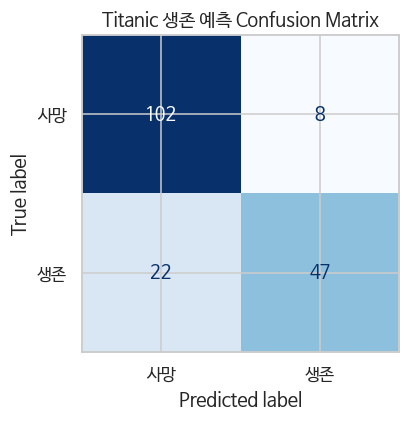

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['사망', '생존']).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
)
ax.set_title('Titanic 생존 예측 Confusion Matrix')
plt.tight_layout()
plt.show()


## 11. Feature Importance 확인

RandomForest는 각 특성이 불순도 감소에 얼마나 기여했는지 `feature_importances_`로 제공합니다. One-hot Encoding 이후의 컬럼명을 가져와 중요도를 확인합니다.


In [ ]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
}).sort_values('importance', ascending=False)

importance_df.head(15)


,feature,importance
4,num__fare,0.157333
10,cat__adult_male_True,0.146170
8,cat__who_man,0.146051
5,cat__sex_male,0.133868
0,num__pclass,0.124075
9,cat__who_woman,0.098202
1,num__age,0.097202
2,num__sibsp,0.041859
7,cat__embarked_S,0.018965
3,num__parch,0.016099


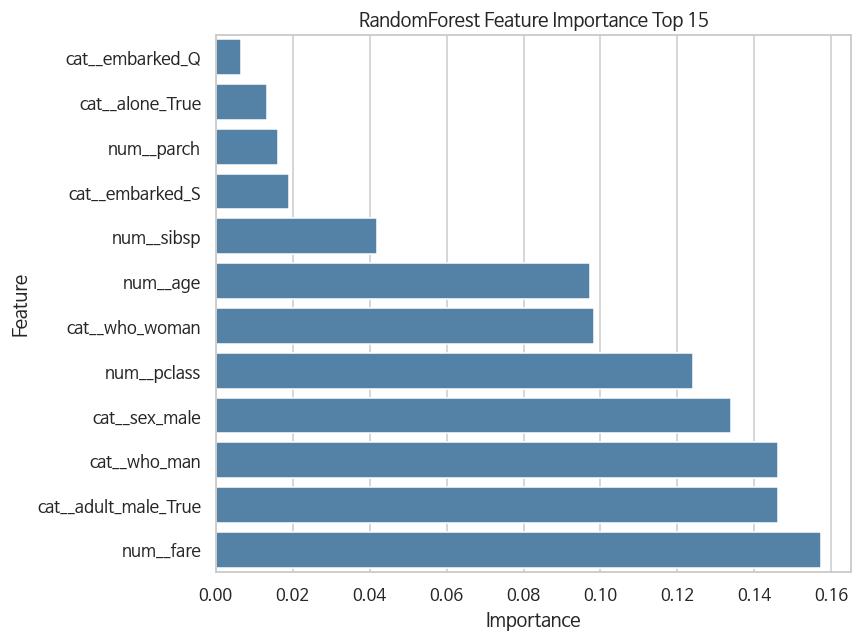

In [ ]:
top_importance = importance_df.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_importance, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('RandomForest Feature Importance Top 15')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


## 12. 교차검증 fold별 클래스 비율 확인

StratifiedKFold가 실제로 각 fold에서 클래스 비율을 비슷하게 유지하는지 확인합니다.


In [ ]:
fold_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
    y_tr_fold = y_train.iloc[train_idx]
    y_va_fold = y_train.iloc[valid_idx]
    fold_rows.append({
        'fold': fold,
        'train_survived_rate': y_tr_fold.mean(),
        'valid_survived_rate': y_va_fold.mean(),
        'train_n': len(y_tr_fold),
        'valid_n': len(y_va_fold),
    })

fold_df = pd.DataFrame(fold_rows)
fold_df.round(4)


,fold,train_survived_rate,valid_survived_rate,train_n,valid_n
0,1,0.3831,0.3846,569,143
1,2,0.3831,0.3846,569,143
2,3,0.3825,0.3873,570,142
3,4,0.3842,0.3803,570,142
4,5,0.3842,0.3803,570,142


## 13. 정리

이번 Lv4 분류 예제에서 배운 흐름은 다음과 같습니다.

1. Titanic 데이터를 `seaborn`에서 불러옵니다.
2. `survived`를 타깃으로 하는 이진 분류 문제를 만듭니다.
3. 학습/테스트 분리에서 `stratify=y`로 층화추출을 적용합니다.
4. 수치형·범주형 변수를 분리하고 `ColumnTransformer`로 전처리합니다.
5. `Pipeline`으로 전처리와 RandomForest 모델을 하나로 묶습니다.
6. `StratifiedKFold`로 층화 교차검증을 진행합니다.
7. `GridSearchCV`로 RandomForest 하이퍼파라미터를 튜닝합니다.
8. 마지막에만 테스트 데이터로 최종 성능을 평가합니다.

다음 단계에서는 threshold 조정, permutation importance, SHAP 등을 연결해볼 수 있습니다.
